In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("AmesHousing.csv")
df.sample(2)

In [ ]:
df.shape

In [ ]:
# Drop Order and PID
df = df.drop(columns=['Order', 'PID'])
df.sample(2)

In [ ]:
missing_values_columns = df.isna().sum()
print(missing_values_columns[missing_values_columns > 0])

In [ ]:
df['Alley'] = df['Alley'].fillna('None')
df['Alley'].sample(4)

df['Fireplace Qu'] = df['Fireplace Qu'].fillna("None")
df['Fireplace Qu'].sample(4)

df['Fence'] = df['Fence'].fillna('None')
df['Fence'].sample(4)

df['Pool QC'] = df['Pool QC'].fillna("None")
df['Pool QC'].sample(4)

df['Misc Feature'] = df['Misc Feature'].fillna("None")
df['Misc Feature'].sample(4)

df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna("None")
df['Mas Vnr Type'].sample(4)

# BsmtFin Type 2, BsmtFin Type 1, Bsmt Exposure, Bsmt Cond, Bsmt Qual
df['BsmtFin Type 2'] = df['BsmtFin Type 2'].fillna("None")
df['BsmtFin Type 2'].sample(4)

df['BsmtFin Type 1'] = df['BsmtFin Type 1'].fillna("None")
df['BsmtFin Type 1'].sample(4)

df['Bsmt Exposure'] = df['Bsmt Exposure'].fillna("None")
df['Bsmt Exposure'].sample(4)

df['Bsmt Cond'] = df['Bsmt Cond'].fillna("None")
df['Bsmt Cond'].sample(4)

df['Bsmt Qual'] = df['Bsmt Qual'].fillna("None")
df['Bsmt Qual'].sample(4)

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Fill the missing value of Total Basement SF with 0 moreover, 
# if the total Basement square feet is 0 then the Basement other features since they are dependent will also be set to none.
df['Total Bsmt SF'] = df['Total Bsmt SF'].fillna(0)
df.loc[
    (df['Total Bsmt SF'] == 0),
    ['BsmtFin Type 2', 'BsmtFin Type 1', 'Bsmt Exposure', 'Bsmt Cond', 'Bsmt Qual']
] = "None"
# BsmtFin SF 1, BsmtFin SF 2, Bsmt Unf SF
df.loc[
    (df['Total Bsmt SF'] == 0),
    ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Bsmt Full Bath', 'Bsmt Half Bath']
] = 0
df['Bsmt Full Bath'] = df['Bsmt Full Bath'].fillna(0)
df['Bsmt Half Bath'] = df['Bsmt Half Bath'].fillna(0)

# If Mansory Venue type is none then the area is subsequently zero.
df.loc[
    (df['Mas Vnr Type'] == 'None') &
    (df['Mas Vnr Area'] != 0),
    'Mas Vnr Area'
] = 0

# If Garage area is 0 then the equivalent column ordinal/nominal shall also be None/0.
df['Garage Area'] = df['Garage Area'].fillna(0)
df.loc[
    (df['Garage Area'] == 0),
    ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']
] = "None"
df['Garage Finish'] = df['Garage Finish'].fillna("None")
df['Garage Qual'] = df['Garage Qual'].fillna("None")
df['Garage Cond'] = df['Garage Cond'].fillna("None")
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)
df.loc[
    (df['Garage Area'] == 0),
    'Garage Cars'
] = 0

df['Lot Frontage'] = (
    df['Lot Frontage'].fillna(df.groupby('Neighborhood')['Lot Frontage'].transform('median'))
)

df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].mode()[0])

- Fill NaN with None
- For Mas Vnr Type Set the equivalent column value Mas Vnr Type to Zero as well.
- For Bsmt if Total Bsmt SF is 0 then the equivalent Basement Columns shall be set to None (Ordinal) or Zero (Nominal)
- Electrical feature only has one missing value set that to mode of any.
- Garage Type replace with None moreover, The equivalent features that do not have any values shall be dropped or filled with Mode.

In [ ]:
missing_values_columns = df.isna().sum()
print(missing_values_columns[missing_values_columns > 0])

#### Exploratory Data Analysis (EDA) 
Exploratory Data Analysis
- Distribution of features
- Distribution of target
- Correlations
- Outliers

**The purpose of EDA:**
Its purpose is to answer four questions:
- What does each feature look like?
- How does each feature relate to the target (SalePrice)?
- How do features relate to one another?
- Are there anomalies (outliers, skewness, leakage, etc.) that require preprocessing?

Whille detecting outliers I had this intuition that outlier in this dataset doesn't necessary has to be removed since every outlier is not an error in the data. For instance, let's understand it through an example that is: if we are studying the wealth distribution in real world. We'll observe not a normal distribution but rather law of power rule. In these scenarios selected number of indiviudal has higher wealth than other people.


In [ ]:
# Numerical Features EDA
numerical_columns = df.select_dtypes(include=np.number)
numerical_columns

In [ ]:
# Studying target variable.

plt.figure(figsize=(8, 5))
plt.hist(df['SalePrice'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Sale Price")
plt.title("Distribution")
plt.show()

print("Taget Skew: ", df['SalePrice'].skew())

In [ ]:
SKEW_Threshold = 1
numerical_columns_skewness = numerical_columns.skew()

filtered = numerical_columns_skewness[
    (numerical_columns_skewness > SKEW_Threshold) |
    (numerical_columns_skewness < -SKEW_Threshold)
]
filtered.to_frame(name="Skewness")

In [ ]:
# ==========================
# Box-Cox Transformation
# (Strictly Positive Features)
# ==========================
# |skew| > 1.

box_cox = PowerTransformer(method='box-cox', standardize=True)

# Target Variable
print("Before SalePrice Skew:", df['SalePrice'].skew())
df['SalePrice'] = box_cox.fit_transform(df[['SalePrice']]).flatten()
print("After SalePrice Skew:", df['SalePrice'].skew())

print("Before Lot Area Skew:", df['Lot Area'].skew())
df['Lot Area'] = box_cox.fit_transform(df[['Lot Area']]).flatten()
print("After Skew:", df['Lot Area'].skew())

print("Before Lot Frontage Skew:", df['Lot Frontage'].skew())
df['Lot Frontage'] = box_cox.fit_transform(df[['Lot Frontage']]).flatten()
print("After Skew:", df['Lot Frontage'].skew())

print("Before 1st Flr SF Skew:", df['1st Flr SF'].skew())
df['1st Flr SF'] = box_cox.fit_transform(df[['1st Flr SF']]).flatten()
print("After Skew:", df['1st Flr SF'].skew())

print("Before Gr Liv Area Skew:", df['Gr Liv Area'].skew())
df['Gr Liv Area'] = box_cox.fit_transform(df[['Gr Liv Area']]).flatten()
print("After Skew:", df['Gr Liv Area'].skew())

In [ ]:
# ==========================
# Yeo-Johnson Transformation
# (Features Containing Zeros)
# ==========================

yeo_johnson = PowerTransformer(method='yeo-johnson', standardize=True)

print("Before Mas Vnr Area Skew:", df['Mas Vnr Area'].skew())
df['Mas Vnr Area'] = yeo_johnson.fit_transform(df[['Mas Vnr Area']]).flatten()
print("After Skew:", df['Mas Vnr Area'].skew())

print("Before BsmtFin SF 1 Skew:", df['BsmtFin SF 1'].skew())
df['BsmtFin SF 1'] = yeo_johnson.fit_transform(df[['BsmtFin SF 1']]).flatten()
print("After Skew:", df['BsmtFin SF 1'].skew())

print("Before BsmtFin SF 2 Skew:", df['BsmtFin SF 2'].skew())
df['BsmtFin SF 2'] = yeo_johnson.fit_transform(df[['BsmtFin SF 2']]).flatten()
print("After Skew:", df['BsmtFin SF 2'].skew())

print("Before Bsmt Unf SF Skew:", df['Bsmt Unf SF'].skew())
df['Bsmt Unf SF'] = yeo_johnson.fit_transform(df[['Bsmt Unf SF']]).flatten()
print("After Skew:", df['Bsmt Unf SF'].skew())

print("Before Total Bsmt SF Skew:", df['Total Bsmt SF'].skew())
df['Total Bsmt SF'] = yeo_johnson.fit_transform(df[['Total Bsmt SF']]).flatten()
print("After Skew:", df['Total Bsmt SF'].skew())

print("Before 2nd Flr SF Skew:", df['2nd Flr SF'].skew())
df['2nd Flr SF'] = yeo_johnson.fit_transform(df[['2nd Flr SF']]).flatten()
print("After Skew:", df['2nd Flr SF'].skew())

print("Before Low Qual Fin SF Skew:", df['Low Qual Fin SF'].skew())
df['Low Qual Fin SF'] = yeo_johnson.fit_transform(df[['Low Qual Fin SF']]).flatten()
print("After Skew:", df['Low Qual Fin SF'].skew())

print("Before Wood Deck SF Skew:", df['Wood Deck SF'].skew())
df['Wood Deck SF'] = yeo_johnson.fit_transform(df[['Wood Deck SF']]).flatten()
print("After Skew:", df['Wood Deck SF'].skew())

print("Before Open Porch SF Skew:", df['Open Porch SF'].skew())
df['Open Porch SF'] = yeo_johnson.fit_transform(df[['Open Porch SF']]).flatten()
print("After Skew:", df['Open Porch SF'].skew())

print("Before Enclosed Porch Skew:", df['Enclosed Porch'].skew())
df['Enclosed Porch'] = yeo_johnson.fit_transform(df[['Enclosed Porch']]).flatten()
print("After Skew:", df['Enclosed Porch'].skew())

print("Before 3Ssn Porch Skew:", df['3Ssn Porch'].skew())
df['3Ssn Porch'] = yeo_johnson.fit_transform(df[['3Ssn Porch']]).flatten()
print("After Skew:", df['3Ssn Porch'].skew())

print("Before Screen Porch Skew:", df['Screen Porch'].skew())
df['Screen Porch'] = yeo_johnson.fit_transform(df[['Screen Porch']]).flatten()
print("After Skew:", df['Screen Porch'].skew())

print("Before Pool Area Skew:", df['Pool Area'].skew())
df['Pool Area'] = yeo_johnson.fit_transform(df[['Pool Area']]).flatten()
print("After Skew:", df['Pool Area'].skew())

print("Before Misc Val Skew:", df['Misc Val'].skew())
df['Misc Val'] = yeo_johnson.fit_transform(df[['Misc Val']]).flatten()
print("After Skew:", df['Misc Val'].skew())

print("Before Bsmt Half Bath Skew:", df['Bsmt Half Bath'].skew())
df['Bsmt Half Bath'] = yeo_johnson.fit_transform(df[['Bsmt Half Bath']]).flatten()
print("After Skew:", df['Bsmt Half Bath'].skew())

print("Before Kitchen AbvGr Skew:", df['Kitchen AbvGr'].skew())
df['Kitchen AbvGr'] = yeo_johnson.fit_transform(df[['Kitchen AbvGr']]).flatten()
print("After Skew:", df['Kitchen AbvGr'].skew())

In [ ]:
categorical_features = df.select_dtypes(exclude=np.number)
print(categorical_features.columns)

In [ ]:
# for col in categorical_features.columns:
#     print(f"\n{'='*50}")
#     print(col)
#     print(df.groupby(col)['SalePrice'].mean().sort_values(ascending=False))

# I was stuck and assuming that if the sale price is affected by the features value then that's an order but I was wrong.

Irrespective of the categorical feature on target variable the object is achieved through one-hot encoding or ordinal encoding which is to convert them into numerical features.

In [74]:
# ==========================
# Encoding Categorical Data
# ==========================
One_Hot_Features = [
    'MS Zoning',
    'Street',
    'Alley',
    'Land Contour',
    'Utilities',
    'Lot Config',
    'Neighborhood',
    'Condition 1',
    'Condition 2',
    'Bldg Type',
    'House Style',
    'Roof Style',
    'Roof Matl',
    'Exterior 1st',
    'Exterior 2nd',
    'Mas Vnr Type',
    'Foundation',
    'Heating',
    'Central Air',
    'Electrical',
    'Garage Type',
    'Paved Drive',
    'Fence',
    'Misc Feature',
    'Sale Type',
    'Sale Condition'
]

In [75]:
# ==========================
# One Hot Encoding (Unorder Categorical Data)
# ==========================

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit and Transform
encoded = encoder.fit_transform(df[One_Hot_Features])

# Create a DataFrame with proper column names
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(One_Hot_Features),
    index=df.index
)

# Remove original categorical columns and join encoded columns
df = pd.concat(
    [df.drop(columns=One_Hot_Features), encoded_df],
    axis=1
)

In [ ]:
# ==========================
# Ordinal Encoding
# ==========================

Ordinal_features = [
    'Exter Qual',       # "TA" "Gd", "Ex", "Fa".                                Ex > Gd > TA > Fa
    'Exter Cond',       # "TA", "Gd", "Fa", "Po", "Ex".                         Ex > Gd > TA > Fa > Po
    'Heating QC',       # 'Fa', 'TA', 'Ex', 'Gd', 'Po'                          Ex > Gd > TA > Fa > Po
    'Kitchen Qual',     # 'TA', 'Gd', 'Ex', 'Fa', 'Po'                          Ex > Gd > TA > Fa > Po
    'Bsmt Qual',        # 'TA', 'Gd', 'Ex', 'None', 'Fa', 'Po'                  Ex > Gd > TA > Fa > Po > None
    'Bsmt Cond',        # 'Gd', 'TA', 'None', 'Po', 'Fa', 'Ex'                  Ex > Gd > TA > Fa > Po > None
    'Fireplace Qu',     # 'Gd', 'None', 'TA', 'Po', 'Ex', 'Fa'                  Ex > Gd > TA > Fa > Po > None
    'Garage Qual',      # 'TA', 'None', 'Fa', 'Gd', 'Ex', 'Po'                  Ex > Gd > TA > Fa > Po > None
    'Garage Cond',      # 'TA', 'None', 'Fa', 'Gd', 'Ex', 'Po'                  Ex > Gd > TA > Fa > Po > None
    'Pool QC',          # 'None', 'Ex', 'Gd', 'TA', 'Fa'                        Ex > Gd > TA > Fa > None
    'Bsmt Exposure',    # 'Gd', 'No', 'Mn', 'Av', 'None'.                       Gd > Av > Mn > No > None
    'BsmtFin Type 1',   # 'BLQ', 'Rec', 'ALQ', 'GLQ', 'Unf', 'LwQ', 'None'      GLQ > ALQ > BLQ > Rec > LwQ > UnF > None    
    'BsmtFin Type 2',   # 'Unf', 'LwQ', 'BLQ', 'Rec', 'None', 'GLQ', 'ALQ'      GLQ > ALQ > BLQ > Rec > LwQ > Unf > None
    'Functional',       # 'Typ', 'Mod', 'Min1', 'Min2', 'Maj1', 'Maj2', 'Sev', 'Sal'  Typ > Min1 > Min2 > Mod > Maj1 > Maj2 > Sev > Sal
    'Garage Finish',    # 'Fin', 'Unf', 'RFn', 'None'                           Fin > RFn > Unf > None
    'Lot Shape',        # 'IR1', 'Reg', 'IR2', 'IR3'                            Reg > IR1 > IR2 > IR3
    'Land Slope',       # 'Gtl', 'Mod', 'Sev'                                   Gtl > Mod > Sev
]

ordinal_categories = [
    ['Fa', 'TA', 'Gd', 'Ex'],                              # Exter Qual
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                        # Exter Cond
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                        # Heating QC
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                        # Kitchen Qual
    ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],               # Bsmt Qual
    ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],               # Bsmt Cond
    ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],               # Fireplace Qu
    ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],               # Garage Qual
    ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],               # Garage Cond
    ['None', 'Fa', 'TA', 'Gd', 'Ex'],                     # Pool QC
    ['None', 'No', 'Mn', 'Av', 'Gd'],                     # Bsmt Exposure
    ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],   # BsmtFin Type 1
    ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],   # BsmtFin Type 2
    ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],  # Functional
    ['None', 'Unf', 'RFn', 'Fin'],                        # Garage Finish
    ['IR3', 'IR2', 'IR1', 'Reg'],                         # Lot Shape
    ['Sev', 'Mod', 'Gtl']                                 # Land Slope
]

In [79]:
encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

df[Ordinal_features] = encoder.fit_transform(df[Ordinal_features])

In [104]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [107]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [108]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae
    })

results_df = pd.DataFrame(results)
results_df.sort_values("RMSE")

,Model,RMSE,MAE
2,Lasso,0.269910,0.186754
1,Ridge,0.271359,0.186704
4,Gradient Boosting,0.277799,0.194734
3,Random Forest,0.298035,0.206221
0,Linear Regression,0.311271,0.184418


In [109]:
for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    rmse = -scores

    print(f"{name}")
    print("RMSE Scores:", rmse)
    print("Average RMSE:", rmse.mean())
    print()

Linear Regression
RMSE Scores: [0.33772197 0.31931066 0.37314172 0.39078189 0.3883706 ]
Average RMSE: 0.3618653679685578

Ridge
RMSE Scores: [0.3336074  0.28909923 0.33447164 0.33011241 0.26856282]
Average RMSE: 0.31117070048662204

Lasso
RMSE Scores: [0.33457131 0.2741863  0.32524633 0.32806082 0.25675153]
Average RMSE: 0.30376325797025033

Random Forest
RMSE Scores: [0.37423262 0.31646565 0.35467787 0.34948106 0.30706409]
Average RMSE: 0.3403842565612704

Gradient Boosting
RMSE Scores: [0.3474973  0.29679836 0.30486071 0.30515426 0.28206367]
Average RMSE: 0.3072748592808294



In [110]:
best_model = GradientBoostingRegressor(random_state=42)

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

residuals = y_test - predictions

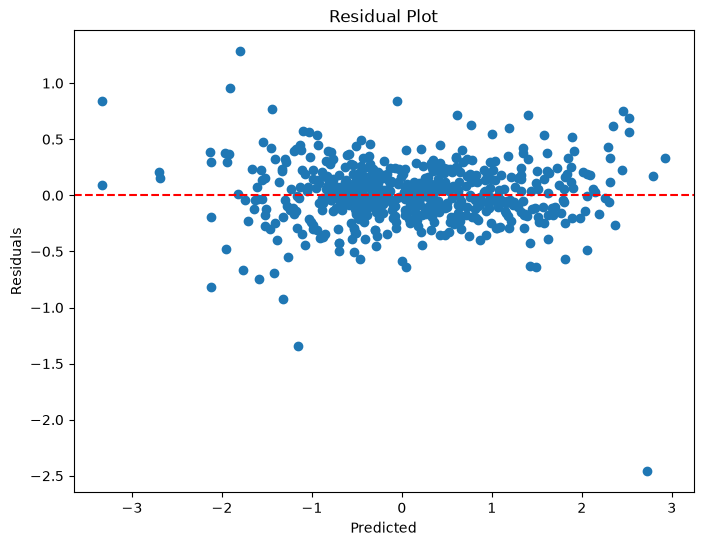

In [111]:
plt.figure(figsize=(8,6))

plt.scatter(
    x=predictions,
    y=residuals
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [114]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
-0.34707071527792427


In [115]:
best_rf = grid_search.best_estimator_

pred = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.2997153102372597
MAE: 0.20488565305944675


In [116]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4],
    "subsample": [0.8, 1.0]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
